<div style="background-color:#247CA6;color:#fff;padding:10px;border-radius:5px">
    Importamos librerias para análisis
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, shapiro

<div style="background-color:#247CA6;color:#fff;padding:10px;border-radius:5px">
    Cargamos dataset 
</div>

In [2]:
tendencias_df = pd.read_csv('../datos/raw/analisis_de_tendencia.csv')

<div style="background-color:#247CA6;color:#fff;padding:10px;border-radius:5px">
    Mostramos información general del dataset
</div>

In [3]:
print(f"Total de columnas: {tendencias_df.shape[1]}, Total de filas: {tendencias_df.shape[0]}")

Total de columnas: 8, Total de filas: 5000


In [4]:
# Info del dataset
tendencias_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id_oferta            5000 non-null   int64 
 1   fecha_publicacion    5000 non-null   object
 2   ciudad               5000 non-null   object
 3   rol                  5000 non-null   object
 4   skills               5000 non-null   object
 5   salario_mensual_mxn  5000 non-null   int64 
 6   exp_requerida        5000 non-null   int64 
 7   modalidad            5000 non-null   object
dtypes: int64(3), object(5)
memory usage: 312.6+ KB


In [5]:
tendencias_df.head()

,id_oferta,fecha_publicacion,ciudad,rol,skills,salario_mensual_mxn,exp_requerida,modalidad
0,1,2024-02-27,GDL,ML Engineer,"Python, SQL",67207,2,remoto
1,2,2024-05-19,MTY,Frontend,"JavaScript, Docker",40537,3,híbrido
2,3,2024-01-22,CDMX,DevOps,"AWS, Docker, Python",44041,5,híbrido
3,4,2024-05-16,CDMX,Data Engineer,"Airflow, Python",50365,3,remoto
4,5,2024-05-25,CDMX,Data Analyst,"Power BI, Tableau, SQL",21676,3,híbrido


In [6]:
# Verificamos la cantidad de nulos
tendencias_df.isnull().sum()

id_oferta              0
fecha_publicacion      0
ciudad                 0
rol                    0
skills                 0
salario_mensual_mxn    0
exp_requerida          0
modalidad              0
dtype: int64

In [7]:
tendencias_df.duplicated().sum()

np.int64(0)

In [8]:
# Describimos nuestro dataset
tendencias_df.describe()

,id_oferta,salario_mensual_mxn,exp_requerida
count,5000.000000,5000.000000,5000.000000
mean,2500.500000,45037.698800,2.395000
std,1443.520003,12149.672931,1.285498
min,1.000000,15000.000000,1.000000
25%,1250.750000,36658.250000,1.000000
50%,2500.500000,44967.500000,2.000000
75%,3750.250000,53571.250000,3.000000
max,5000.000000,86029.000000,5.000000


In [9]:
# Estanrarizamos dataset si es necesario
def estandar_columnas (df):
    df.columns = (df.columns.str.strip().str.lower().str.replace(' ', '_', regex=False).str.replace('.', '', regex=False))
    return df
# Mandamos dataset a estandarizar
estandar_columnas(tendencias_df)

,id_oferta,fecha_publicacion,ciudad,rol,skills,salario_mensual_mxn,exp_requerida,modalidad
0,1,2024-02-27,GDL,ML Engineer,"Python, SQL",67207,2,remoto
1,2,2024-05-19,MTY,Frontend,"JavaScript, Docker",40537,3,híbrido
2,3,2024-01-22,CDMX,DevOps,"AWS, Docker, Python",44041,5,híbrido
3,4,2024-05-16,CDMX,Data Engineer,"Airflow, Python",50365,3,remoto
4,5,2024-05-25,CDMX,Data Analyst,"Power BI, Tableau, SQL",21676,3,híbrido
...,...,...,...,...,...,...,...,...
4995,4996,2024-06-10,MTY,Frontend,"JavaScript, Docker",41029,5,presencial
4996,4997,2024-04-09,CDMX,ML Engineer,"Python, SQL, Pandas, AWS",57137,1,presencial
4997,4998,2024-06-10,CDMX,Data Engineer,"SQL, Python",62957,2,remoto
4998,4999,2024-04-21,CDMX,DevOps,"Docker, Python, AWS",50112,1,remoto


In [54]:
# Detectamos outliers
columnas_num = ['salario_mensual_mxn','exp_requerida']

# Método IQR para detectar outliers
for col in columnas_num:
    Q1 = tendencias_df[col].quantile(0.25)
    Q3 = tendencias_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = tendencias_df[(tendencias_df[col] < lower) | (tendencias_df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(tendencias_df)*100:.2f}%)")
    # Imprimimos los outliers
    if len(outliers) > 0:
        print(outliers[[col]])

salario_mensual_mxn: 3 outliers (0.06%)
      salario_mensual_mxn
2599                80454
3037                79728
3789                86029
exp_requerida: 0 outliers (0.00%)


In [11]:
filtro = tendencias_df['salario_mensual_mxn'].isin([80454,79728,86029])
print(tendencias_df[filtro][['rol','salario_mensual_mxn']] )

              rol  salario_mensual_mxn
2599      Backend                80454
3037  ML Engineer                79728
3789  ML Engineer                86029


<div style="background-color:#EBDD73;color:#000;padding:10px;border-radius:5px">
    A pesar de tener 3 outliers en <b>salario_mensual_mxn</b> no se condieran datos extremos como para eliminarlos, lo que si sería importante saber es si son trabajos con nivel senior que nos permita comprobar que el salario concuerda con el puesto.
</div>

<div style="background-color:#F09241;color:#fff;padding:10px;border-radius:5px">
    Gráficos
</div>

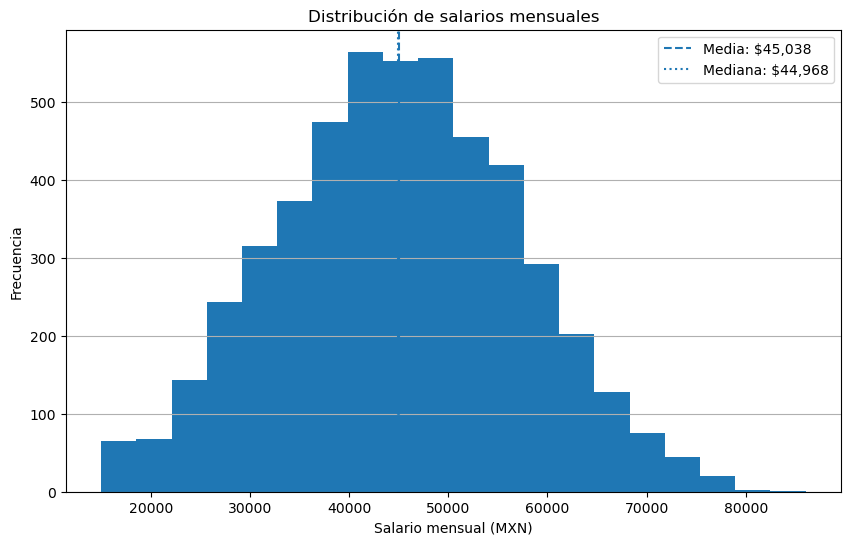

In [5]:
# Histograma
plt.figure(figsize=(10, 6))
plt.hist(tendencias_df['salario_mensual_mxn'], bins=20)
plt.title('Distribución de salarios mensuales')
plt.xlabel('Salario mensual (MXN)')
plt.ylabel('Frecuencia')
media = tendencias_df['salario_mensual_mxn'].mean()
mediana = tendencias_df['salario_mensual_mxn'].median()
plt.axvline(media, linestyle='--', label=f'Media: ${media:,.0f}')
plt.axvline(mediana, linestyle=':', label=f'Mediana: ${mediana:,.0f}')
plt.grid(axis='y')
plt.legend()
# Guardamos output
plt.savefig('../outputs/distribucion_salarios.png', dpi=300, bbox_inches='tight')
# Mostramos
plt.show()

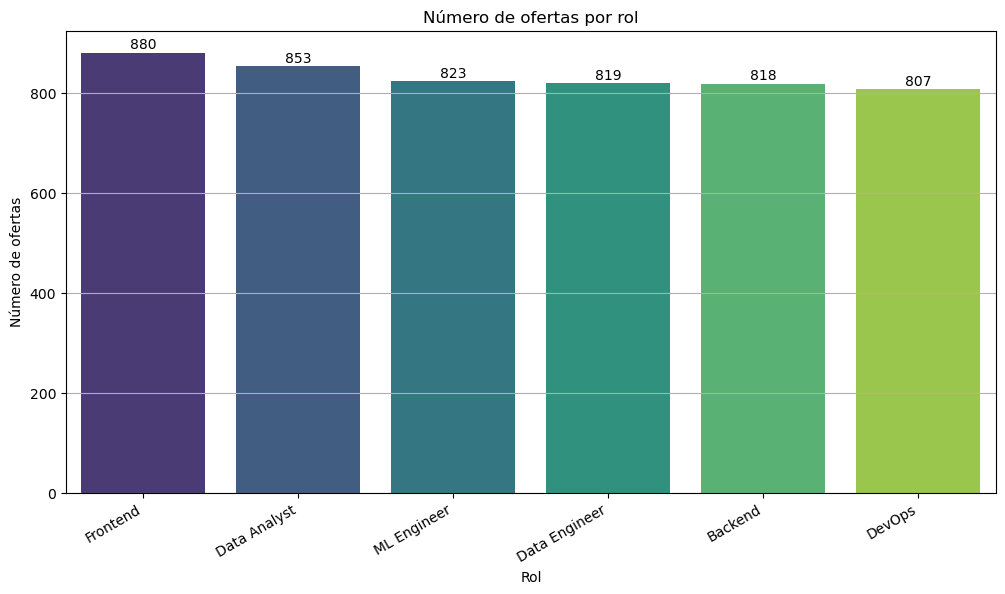

In [6]:
# Gráfico de barras para roles
roles = tendencias_df['rol'].value_counts().sort_values(ascending=False)
# Gráfico de barras
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=roles.index,
    y=roles.values,
    hue=roles.index,
    palette='viridis',
    legend=False
)
for i, valor in enumerate(roles.values):
    ax.text(i,valor+8,str(valor),ha='center')
plt.title('Número de ofertas por rol')
plt.xlabel('Rol')
plt.ylabel('Número de ofertas')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y')
# Guardar output
plt.savefig('../outputs/cantidad_ofertas_rol.png', dpi=300, bbox_inches='tight')
# Mostramos
plt.show()

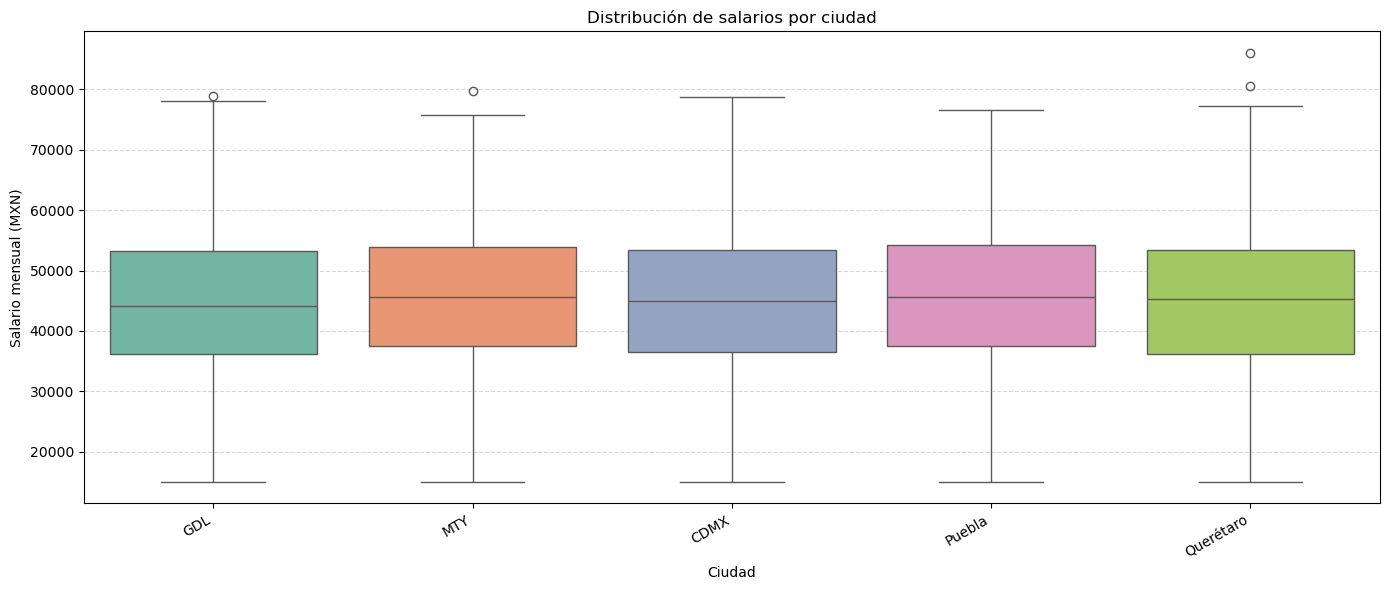

In [7]:
# Boxplot de salarios por ciudad
plt.figure(figsize=(14, 6))
ax = sns.boxplot(
    x='ciudad',
    y='salario_mensual_mxn',
    data=tendencias_df,
    hue='ciudad',
    palette='Set2'
)
plt.title('Distribución de salarios por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Salario mensual (MXN)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# Guardamos output
plt.savefig('../outputs/distribucion_salarios_ciudad.png', dpi=300, bbox_inches='tight')
# Mostramos
plt.show()

In [57]:
# Generamos tabla de salarios promedio por rol y ciudad
salarios_rol_ciudad = tendencias_df.groupby(['rol', 'ciudad', 'exp_requerida'])['salario_mensual_mxn'].mean().reset_index().sort_values(by='salario_mensual_mxn', ascending=False)
# Ajustamos formato de salario a dos decimales y con separadores de miles
salarios_rol_ciudad.head(10)

,rol,ciudad,exp_requerida,salario_mensual_mxn
142,ML Engineer,Puebla,3,60587.862069
146,ML Engineer,Querétaro,2,59339.541667
138,ML Engineer,MTY,4,58606.181818
130,ML Engineer,GDL,1,57483.886792
128,ML Engineer,CDMX,4,56957.710526
139,ML Engineer,MTY,5,56946.631579
140,ML Engineer,Puebla,1,56262.111111
132,ML Engineer,GDL,3,55978.074074
133,ML Engineer,GDL,4,55933.375000
93,DevOps,Puebla,4,55890.363636


In [81]:
# Roles que en CDMX tienen un salario promedio mayor a 60,000 MXN y ordénalos de mayor a menor
cdmx_roles = salarios_rol_ciudad[(salarios_rol_ciudad['ciudad'] == 'CDMX') & (salarios_rol_ciudad['salario_mensual_mxn'] > 60000)].sort_values(by='salario_mensual_mxn', ascending=False)
cdmx_roles.head(10)
#tendencias_df[tendencias_df['ciudad'] == 'CDMX'].groupby('rol')['salario_mensual_mxn'].mean().reset_index().sort_values(by='salario_mensual_mxn', ascending=False).head(10)

,rol,ciudad,exp_requerida,salario_mensual_mxn


In [73]:
# Los roles remotos pagan significativamente distinto que los presenciales? (prueba t-test)
# Grupos
remotos = tendencias_df.loc[tendencias_df['modalidad'] == 'remoto','salario_mensual_mxn']
presenciales = tendencias_df.loc[tendencias_df['modalidad'] == 'presencial','salario_mensual_mxn']
hibridos = tendencias_df.loc[tendencias_df['modalidad'] == 'híbrido','salario_mensual_mxn']
# Estadísticas descriptivas
print(f"Remotos: {len(remotos)} observaciones")
print(f"Presenciales: {len(presenciales)} observaciones")
print(f"Híbridos: {len(hibridos)} observaciones")
print("=" * 30)
print("Salario promedio")
print(f"Remotos: ${remotos.mean():,.2f}")
print(f"Presenciales: ${presenciales.mean():,.2f}")
print(f"Híbridos: ${hibridos.mean():,.2f}")
# ANOVA
f_stat, p_value = f_oneway(
    remotos,
    presenciales,
    hibridos
)
# Resultados
print("=" * 30)
print("Resultados ANOVA")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print("=" * 30)
# Valor de significancia
alpha = 0.05
# Interpretación
if p_value < alpha:
    print("Se rechaza H0: Existe diferencia salarial significativa entre al menos una modalidad.")
else:
    print("No se rechaza H0: No existe evidencia suficiente de diferencias salariales entre modalidades.")


Remotos: 1987 observaciones
Presenciales: 996 observaciones
Híbridos: 2017 observaciones
Salario promedio
Remotos: $45,159.41
Presenciales: $44,625.27
Híbridos: $45,121.45
Resultados ANOVA
F-statistic: 0.7214
P-value: 0.4861
No se rechaza H0: No existe evidencia suficiente de diferencias salariales entre modalidades.


<div style="background-color:#4DB08B;color:#000;padding:10px;border-radius:5px">
    Conclusiones iniciales:
</div>

In [82]:
# ¿Qué ciudad paga mejor para Data Analyst? (con exp filtrada)
data_analyst_ciudades = tendencias_df[tendencias_df['rol'] == 'Data Analyst'].groupby('ciudad')['salario_mensual_mxn'].mean().reset_index().sort_values(by='salario_mensual_mxn', ascending=False)
data_analyst_ciudades.head(10)

,ciudad,salario_mensual_mxn
3,Puebla,36086.397849
0,CDMX,35032.430723
4,Querétaro,34966.573171
2,MTY,34738.143791
1,GDL,34299.854922


In [83]:
# Skills más demandados
skills = tendencias_df['skills'].str.lower().str.split(',').explode().str.strip().value_counts().reset_index()
skills.columns = ['skill', 'count']
skills.head(5)

,skill,count
0,python,3162
1,aws,2537
2,docker,2180
3,sql,1865
4,javascript,880


In [91]:
skills_df = skills.head(10)  # skills es tu DataFrame de skills contadas
skills_df.to_csv('../datos/processed/top_skills.csv', index=False)

In [85]:
# ¿Los salarios siguen distribución normal?
stat, p = shapiro(tendencias_df['salario_mensual_mxn'])
print(f"Shapiro-Wilk Test: Statistic={stat:.4f}, p-value={p:.4f}")
if p > 0.05:
    print("Los salarios siguen una distribución normal.")
else:
    print("Los salarios no siguen una distribución normal.")

Shapiro-Wilk Test: Statistic=0.9978, p-value=0.0000
Los salarios no siguen una distribución normal.


In [ ]:
tendencias_df.to_csv('../datos/processed/analisis_de_tendencia_tableau.csv', index=False, encoding='utf-8-sig')
print("Archivo guardado. Ubicación: datos/processed/analisis_de_tendencia_tableau.csv")

Archivo guardado. Ubicación: datos/processed/analisis_de_tendencia_looker.csv
